In [3]:
# =========================================================
# PERTEMUAN 4 — HANDS ON DATASET IRIS
# Statistika Dasar & Analisis Data
# =========================================================

# =========================================================
# Langkah 0 — Import Library
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style visualisasi
sns.set_style("whitegrid")

In [4]:
# =========================================================
# Langkah 1 — Load & Inspect Dataset
# =========================================================

# Load dataset iris
df = sns.load_dataset('iris')

# Menampilkan shape dataset
print("Shape Dataset:")
print(df.shape)

# Menampilkan tipe data
print("\nTipe Data:")
print(df.dtypes)

# Menampilkan 5 data pertama
print("\nHead Dataset:")
print(df.head())

# Statistik deskriptif
print("\nDescriptive Statistics:")
print(df.describe().round(3))


Shape Dataset:
(150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Head Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Descriptive Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350

In [5]:
# =========================================================
# Langkah 2 — Statistik Deskriptif Lengkap
# =========================================================

print("\n=================================================")
print("STATISTIK DESKRIPTIF")
print("=================================================")

for col_name in df.select_dtypes(include='number').columns:

    col = df[col_name]

    print(f"\n=== {col_name.upper()} ===")
    print(f"Mean      : {col.mean():.3f}")
    print(f"Median    : {col.median():.3f}")
    print(f"Std Dev   : {col.std():.3f}")
    print(f"Varians   : {col.var():.3f}")
    print(f"Skewness  : {col.skew():.3f}")
    print(f"Kurtosis  : {col.kurt():.3f}")


STATISTIK DESKRIPTIF

=== SEPAL_LENGTH ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Varians   : 0.686
Skewness  : 0.315
Kurtosis  : -0.552

=== SEPAL_WIDTH ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Varians   : 0.190
Skewness  : 0.319
Kurtosis  : 0.228

=== PETAL_LENGTH ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Varians   : 3.116
Skewness  : -0.275
Kurtosis  : -1.402

=== PETAL_WIDTH ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Varians   : 0.581
Skewness  : -0.103
Kurtosis  : -1.341


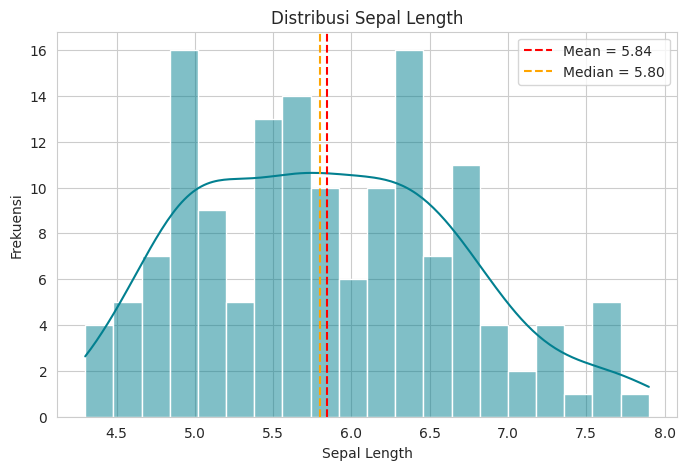


INTERPRETASI DISTRIBUSI
Nilai Skewness : 0.315
Distribusi cenderung Normal / Simetris


In [6]:
# =========================================================
# Langkah 3 — Analisis Distribusi
# Histogram + KDE
# =========================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

# Garis mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Frekuensi')

ax.legend()

plt.show()

# Interpretasi distribusi
print("\n=================================================")
print("INTERPRETASI DISTRIBUSI")
print("=================================================")

skewness = df['sepal_length'].skew()

print(f"Nilai Skewness : {skewness:.3f}")

if skewness > 0.5:
    print("Distribusi termasuk Right-Skewed")
elif skewness < -0.5:
    print("Distribusi termasuk Left-Skewed")
else:
    print("Distribusi cenderung Normal / Simetris")

/tmp/ipykernel_7102/3079449987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7102/3079449987.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


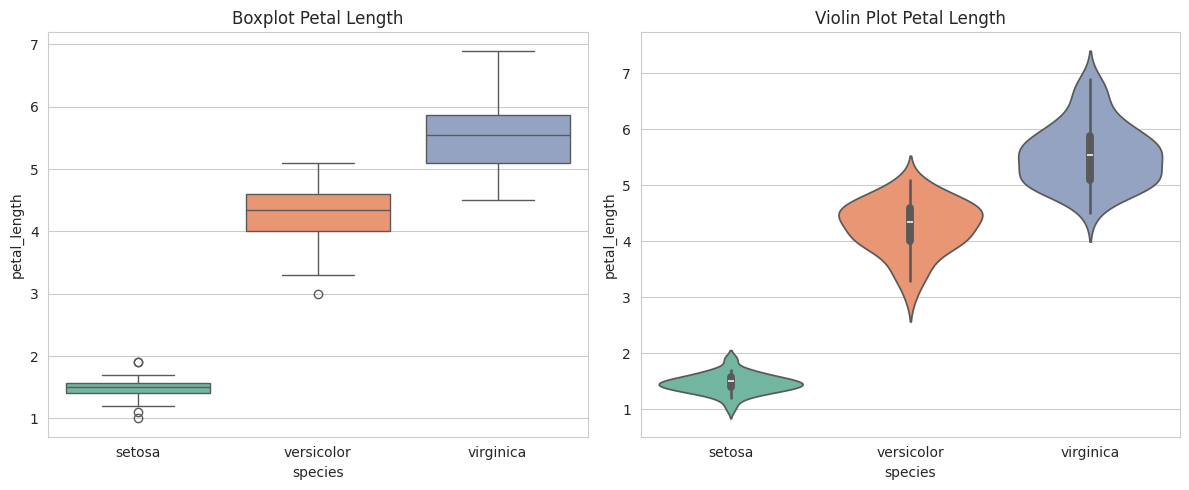


INTERPRETASI BOXPLOT
- Setosa memiliki petal_length paling kecil.
- Virginica memiliki petal_length paling besar.
- Virginica juga memiliki persebaran data paling luas.
- Versicolor berada di tengah antara Setosa dan Virginica.


In [7]:
# =========================================================
# Langkah 4 — Boxplot per Spesies
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

# Violin plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

# Interpretasi
print("\n=================================================")
print("INTERPRETASI BOXPLOT")
print("=================================================")

print("- Setosa memiliki petal_length paling kecil.")
print("- Virginica memiliki petal_length paling besar.")
print("- Virginica juga memiliki persebaran data paling luas.")
print("- Versicolor berada di tengah antara Setosa dan Virginica.")



In [8]:
# =========================================================
# Langkah 5 — Matriks Korelasi Pearson
# =========================================================

corr = df.drop('species', axis=1).corr(method='pearson')

print("\n=================================================")
print("MATRIKS KORELASI")
print("=================================================")

print(corr.round(3))

# Mencari pasangan korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(f"\nKorelasi tertinggi: {max_pair}")
print(f"Nilai korelasi: {corr.loc[max_pair]:.3f}")



MATRIKS KORELASI
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length')
Nilai korelasi: 0.963


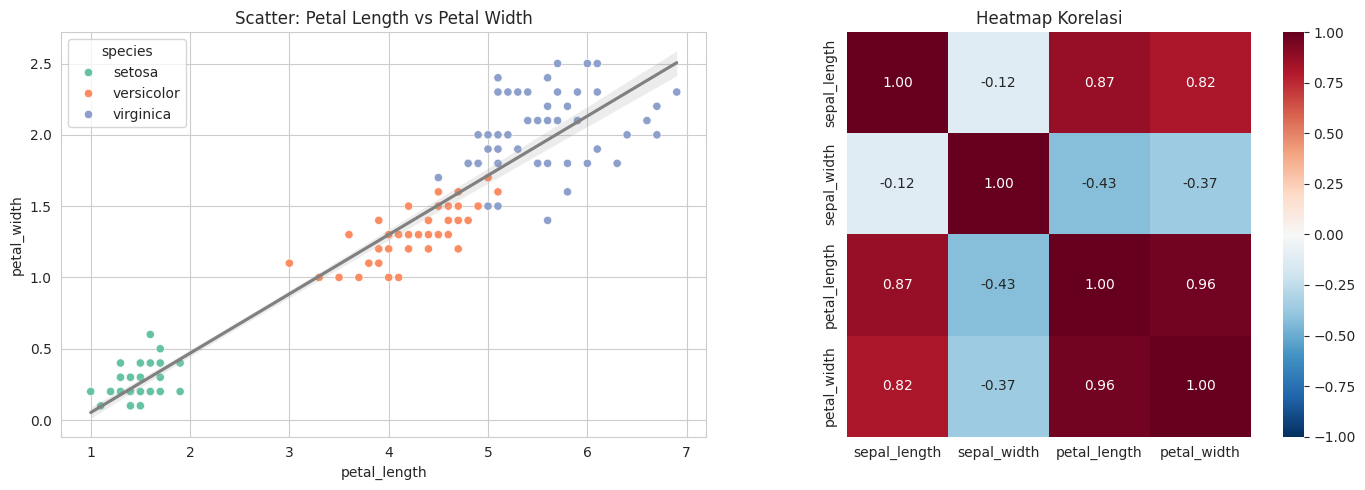

In [9]:
# =========================================================
# Langkah 6 — Scatter Plot & Heatmap
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

# Garis regresi
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

# Heatmap korelasi
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()


In [10]:
# =========================================================
# INTERPRETASI AKHIR
# =========================================================

print("\n=================================================")
print("INTERPRETASI AKHIR")
print("=================================================")

print("""
1. Variabel petal_length dan petal_width memiliki
   korelasi positif yang sangat kuat.

2. Semakin panjang petal bunga, maka umumnya
   semakin lebar petal tersebut.

3. Scatter plot menunjukkan pemisahan spesies
   yang cukup jelas.

4. Spesies setosa terlihat paling berbeda dibanding
   versicolor dan virginica.

5. Heatmap memperlihatkan bahwa sebagian besar
   variabel memiliki hubungan positif.

6. Korelasi negatif lemah terlihat pada sepal_width
   terhadap beberapa variabel lain.
""")


INTERPRETASI AKHIR

1. Variabel petal_length dan petal_width memiliki
   korelasi positif yang sangat kuat.

2. Semakin panjang petal bunga, maka umumnya
   semakin lebar petal tersebut.

3. Scatter plot menunjukkan pemisahan spesies
   yang cukup jelas.

4. Spesies setosa terlihat paling berbeda dibanding
   versicolor dan virginica.

5. Heatmap memperlihatkan bahwa sebagian besar
   variabel memiliki hubungan positif.

6. Korelasi negatif lemah terlihat pada sepal_width
   terhadap beberapa variabel lain.

